# WeIntern AIML Internship — Week 1
**Student Performance Dataset Analysis**

**Author:** Aman Sharma  
**Date:** 04 June 2026

**Tasks:** Data Cleaning | Visualization | Business Insights

TASK 1 : Data Loading & Cleaning

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style='whitegrid')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [24]:
df = pd.read_csv('../data/raw/student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 10000 rows, 6 columns


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.00
1,4,82,No,4,2,65.00
2,8,51,Yes,7,2,45.00
3,5,52,Yes,5,2,36.00
4,7,75,No,8,5,66.00


In [25]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== BASIC STATS ===")
df.describe()

=== DATA TYPES ===
Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

=== MISSING VALUES ===
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

=== DUPLICATES ===


Duplicate rows: 127

=== BASIC STATS ===


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4.99,69.45,6.53,4.58,55.22
std,2.59,17.34,1.70,2.87,19.21
min,1.00,40.00,4.00,0.00,10.00
25%,3.00,54.00,5.00,2.00,40.00
50%,5.00,69.00,7.00,5.00,55.00
75%,7.00,85.00,8.00,7.00,71.00
max,9.00,99.00,9.00,9.00,100.00


In [26]:
# Step 1: Original dataset backup
df_raw = df.copy()

# Step 2: Remove duplicates
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")

# Step 3: Standardize categorical labels
print("\nExtracurricular Activities unique values BEFORE:")
print(df['Extracurricular Activities'].unique())

df['Extracurricular Activities'] = df['Extracurricular Activities'].str.strip().str.capitalize()

print("\nExtracurricular Activities unique values AFTER:")
print(df['Extracurricular Activities'].unique())

# Step 4: Rename columns (remove spaces for easier coding)
df.columns = df.columns.str.strip().str.replace(' ', '_')
print("\nNew column names:")
print(df.columns.tolist())

# Step 5: Save cleaned dataset
df.to_csv('../data/cleaned/student_performance_cleaned.csv', index=False)
print("\nCleaned dataset saved!")
print(f"Final shape: {df.shape}")

Rows after removing duplicates: 9873

Extracurricular Activities unique values BEFORE:
['Yes' 'No']

Extracurricular Activities unique values AFTER:
['Yes' 'No']

New column names:
['Hours_Studied', 'Previous_Scores', 'Extracurricular_Activities', 'Sleep_Hours', 'Sample_Question_Papers_Practiced', 'Performance_Index']

Cleaned dataset saved!
Final shape: (9873, 6)


In [27]:
feature_info = {
    'Column': ['Hours_Studied', 'Previous_Scores', 'Extracurricular_Activities', 
               'Sleep_Hours', 'Sample_Question_Papers_Practiced', 'Performance_Index'],
    'Type': ['Numerical', 'Numerical', 'Categorical', 
             'Numerical', 'Numerical', 'Target (Numerical)'],
    'Description': [
        'Number of hours studied per week (1-9)',
        'Scores from previous exams (40-99)',
        'Whether student does extracurricular activities (Yes/No)',
        'Average sleep hours per night (4-9)',
        'Number of sample papers practiced (0-9)',
        'Final performance score - TARGET variable (10-100)'
    ],
    'Influences_Target': ['Yes', 'Yes', 'Possibly', 'Possibly', 'Yes', '-']
}

feature_df = pd.DataFrame(feature_info)
print("=== FEATURE OVERVIEW TABLE ===\n")
feature_df

=== FEATURE OVERVIEW TABLE ===



,Column,Type,Description,Influences_Target
0,Hours_Studied,Numerical,Number of hours studied per week (1-9),Yes
1,Previous_Scores,Numerical,Scores from previous exams (40-99),Yes
2,Extracurricular_Activities,Categorical,Whether student does extracurricular activitie...,Possibly
3,Sleep_Hours,Numerical,Average sleep hours per night (4-9),Possibly
4,Sample_Question_Papers_Practiced,Numerical,Number of sample papers practiced (0-9),Yes
5,Performance_Index,Target (Numerical),Final performance score - TARGET variable (10-...,-


In [28]:
# Groupby analysis
print("=== AVG PERFORMANCE BY EXTRACURRICULAR ACTIVITIES ===")
print(df.groupby('Extracurricular_Activities')['Performance_Index'].mean().round(2))

print("\n=== AVG PERFORMANCE BY STUDY HOURS ===")
print(df.groupby('Hours_Studied')['Performance_Index'].mean().round(2))

print("\n=== AVG PERFORMANCE BY SAMPLE PAPERS PRACTICED ===")
print(df.groupby('Sample_Question_Papers_Practiced')['Performance_Index'].mean().round(2))

=== AVG PERFORMANCE BY EXTRACURRICULAR ACTIVITIES ===
Extracurricular_Activities
No    54.72
Yes   55.72
Name: Performance_Index, dtype: float64

=== AVG PERFORMANCE BY STUDY HOURS ===
Hours_Studied
1   43.98
2   46.45
3   49.76
4   52.78
5   55.50
6   58.48
7   60.22
8   64.18
9   65.81
Name: Performance_Index, dtype: float64

=== AVG PERFORMANCE BY SAMPLE PAPERS PRACTICED ===
Sample_Question_Papers_Practiced
0   52.95
1   54.69
2   55.14
3   55.27
4   54.12
5   55.30
6   56.18
7   55.89
8   55.49
9   56.82
Name: Performance_Index, dtype: float64


In [29]:
observations = """
=== 8 KEY OBSERVATIONS FROM DATASET ===

1. STUDY HOURS - STRONGEST DRIVER:
   Students studying 1hr/week score avg 43.98 vs 9hrs = 65.81.
   Nearly 22 point difference — strongest predictor of performance.

2. EXTRACURRICULAR ACTIVITIES - MINIMAL IMPACT:
   Yes = 55.72 vs No = 54.72 (only 1 point difference).
   Extracurricular participation does NOT significantly affect scores.

3. SAMPLE PAPERS - WEAK EFFECT:
   0 papers = 52.95 vs 9 papers = 56.82 (only ~4 point difference).
   Practicing sample papers has limited standalone impact.

4. PERFORMANCE DISTRIBUTION:
   Mean = 55.22, Std = 19.21, Range = 10 to 100.
   Wide spread suggests multiple factors influence outcomes.

5. STUDY HOURS ARE CONSISTENT:
   Every extra hour of study adds ~2.5 points on average.
   The relationship appears linear and consistent.

6. SLEEP HOURS - MODERATE EFFECT:
   Performance varies across sleep hours but not dramatically.
   Extreme undersleep or oversleep may negatively affect scores.

7. PREVIOUS SCORES LIKELY STRONG PREDICTOR:
   Range 40-99 with mean 69.45 — prior academic performance
   is likely highly correlated with current Performance Index.

8. DATA QUALITY:
   Zero missing values, 127 duplicates removed (1.27% of data).
   Dataset is clean and reliable for analysis.
"""

print(observations)


=== 8 KEY OBSERVATIONS FROM DATASET ===

1. STUDY HOURS - STRONGEST DRIVER:
   Students studying 1hr/week score avg 43.98 vs 9hrs = 65.81.
   Nearly 22 point difference — strongest predictor of performance.

2. EXTRACURRICULAR ACTIVITIES - MINIMAL IMPACT:
   Yes = 55.72 vs No = 54.72 (only 1 point difference).
   Extracurricular participation does NOT significantly affect scores.

3. SAMPLE PAPERS - WEAK EFFECT:
   0 papers = 52.95 vs 9 papers = 56.82 (only ~4 point difference).
   Practicing sample papers has limited standalone impact.

4. PERFORMANCE DISTRIBUTION:
   Mean = 55.22, Std = 19.21, Range = 10 to 100.
   Wide spread suggests multiple factors influence outcomes.

5. STUDY HOURS ARE CONSISTENT:
   Every extra hour of study adds ~2.5 points on average.
   The relationship appears linear and consistent.

6. SLEEP HOURS - MODERATE EFFECT:
   Performance varies across sleep hours but not dramatically.
   Extreme undersleep or oversleep may negatively affect scores.

7. PREVIOUS

TASK 2 : Visualizations

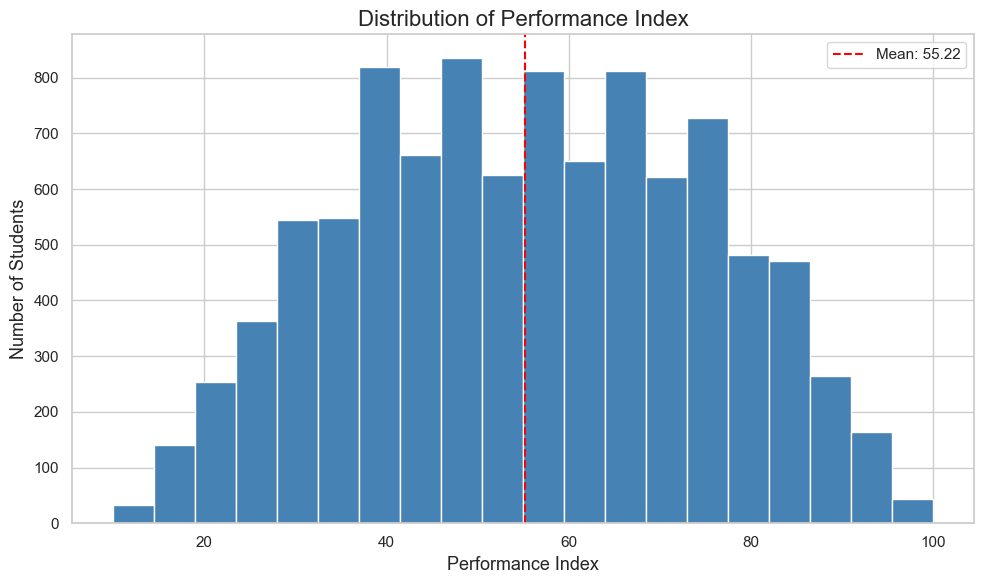

Chart saved!


In [30]:
plt.figure(figsize=(10, 6))
plt.hist(df['Performance_Index'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Performance Index', fontsize=16)
plt.xlabel('Performance Index', fontsize=13)
plt.ylabel('Number of Students', fontsize=13)
plt.axvline(df['Performance_Index'].mean(), color='red', linestyle='--', label=f"Mean: {df['Performance_Index'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

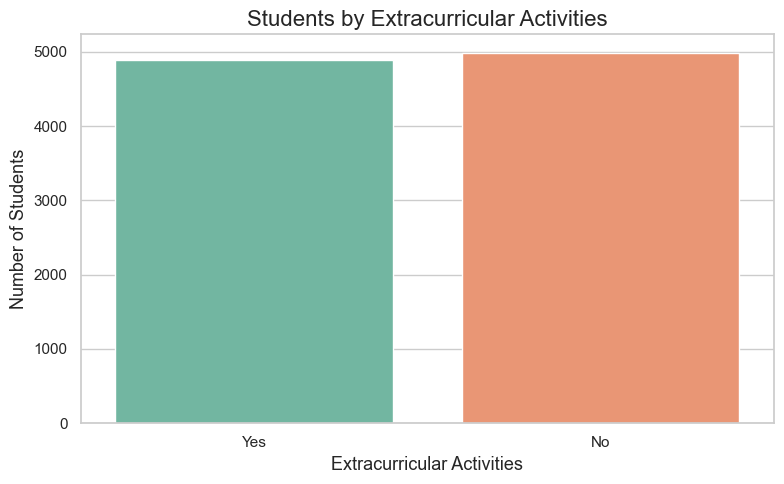

Chart saved!


In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Extracurricular_Activities', data=df, 
              hue='Extracurricular_Activities', palette='Set2', legend=False)
plt.title('Students by Extracurricular Activities', fontsize=16)
plt.xlabel('Extracurricular Activities', fontsize=13)
plt.ylabel('Number of Students', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/charts/extracurricular_countplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

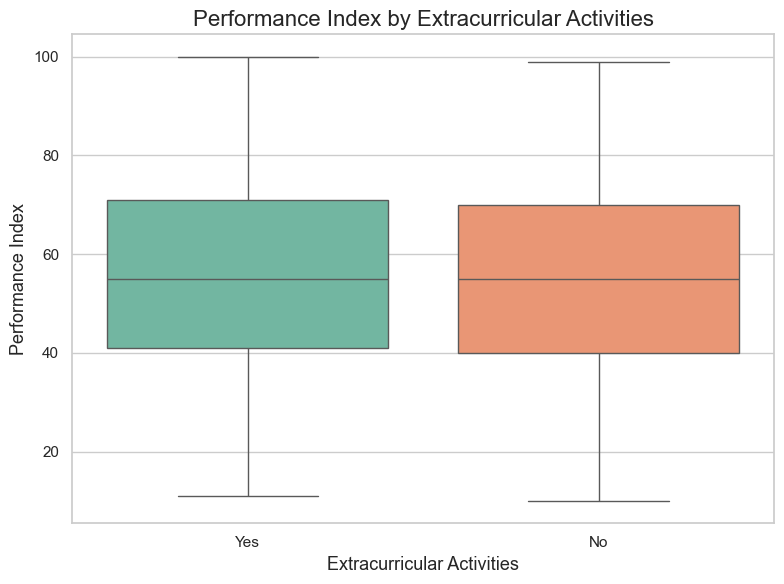

Chart saved!


In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Extracurricular_Activities', y='Performance_Index', 
            data=df, hue='Extracurricular_Activities', palette='Set2', legend=False)
plt.title('Performance Index by Extracurricular Activities', fontsize=16)
plt.xlabel('Extracurricular Activities', fontsize=13)
plt.ylabel('Performance Index', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/charts/boxplot_extracurricular.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

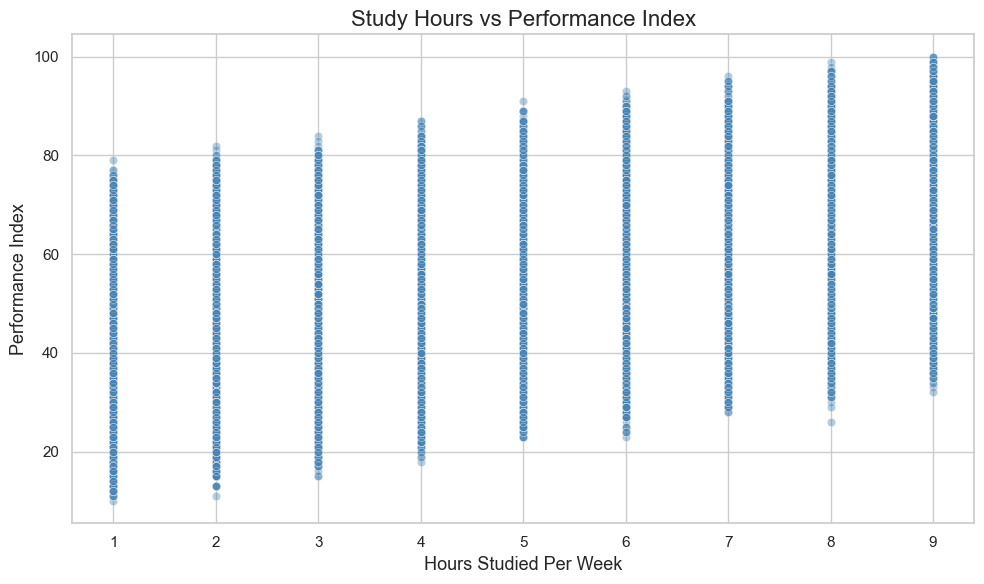

Chart saved!


In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours_Studied', y='Performance_Index', 
                data=df, alpha=0.4, color='steelblue')
plt.title('Study Hours vs Performance Index', fontsize=16)
plt.xlabel('Hours Studied Per Week', fontsize=13)
plt.ylabel('Performance Index', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/charts/scatter_studyhours_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

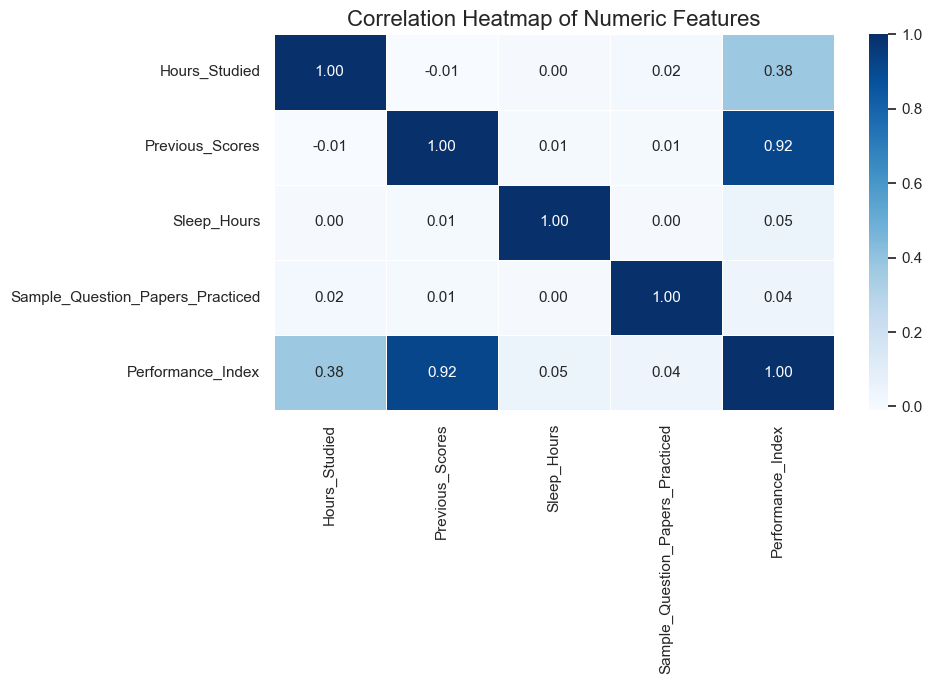

Chart saved!


In [34]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', 
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.tight_layout()
plt.savefig('../outputs/charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

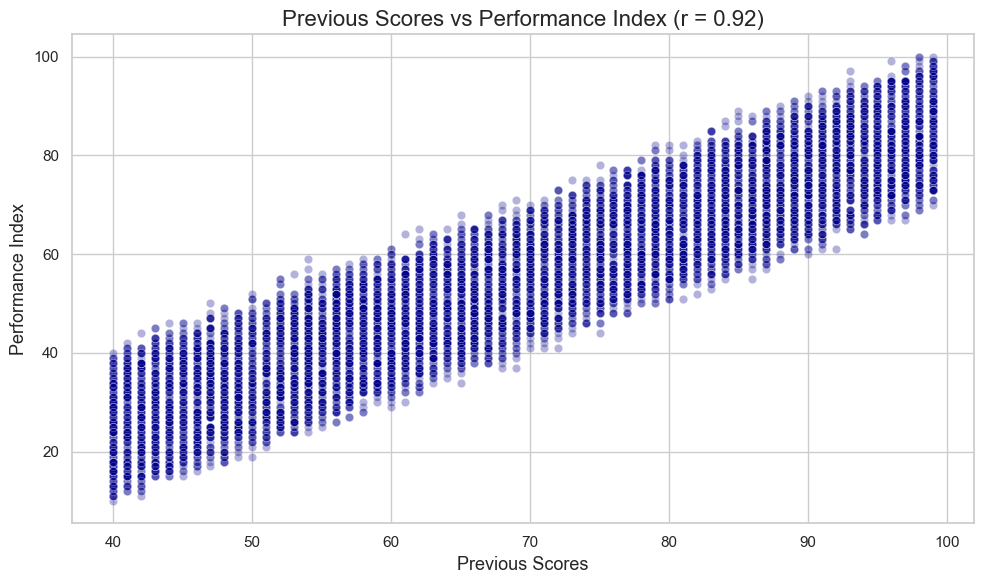

Chart saved!


In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Previous_Scores', y='Performance_Index', 
                data=df, alpha=0.3, color='darkblue')
plt.title('Previous Scores vs Performance Index (r = 0.92)', fontsize=16)
plt.xlabel('Previous Scores', fontsize=13)
plt.ylabel('Performance Index', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/charts/scatter_previousscores_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [36]:
print("""
=== CORRELATION HEATMAP INSIGHTS ===

1. STRONGEST CORRELATION (0.92):
   Previous_Scores vs Performance_Index — near perfect positive correlation.
   Past academic performance is by far the strongest predictor of current score.

2. MODERATE CORRELATION (0.38):
   Hours_Studied vs Performance_Index — meaningful but not dominant.
   Study time helps, but previous scores matter much more.

3. NEGLIGIBLE CORRELATIONS:
   Sleep_Hours (0.05) and Sample_Question_Papers_Practiced (0.04)
   show almost zero linear relationship with Performance_Index.

4. INDEPENDENT FEATURES:
   All input features are nearly uncorrelated with each other (close to 0.00),
   which means no multicollinearity — good for future ML modeling.

5. CAUSATION WARNING:
   High correlation between Previous_Scores and Performance_Index does NOT
   mean past scores CAUSE good performance — other hidden factors may exist.
""")


=== CORRELATION HEATMAP INSIGHTS ===

1. STRONGEST CORRELATION (0.92):
   Previous_Scores vs Performance_Index — near perfect positive correlation.
   Past academic performance is by far the strongest predictor of current score.

2. MODERATE CORRELATION (0.38):
   Hours_Studied vs Performance_Index — meaningful but not dominant.
   Study time helps, but previous scores matter much more.

3. NEGLIGIBLE CORRELATIONS:
   Sleep_Hours (0.05) and Sample_Question_Papers_Practiced (0.04)
   show almost zero linear relationship with Performance_Index.

4. INDEPENDENT FEATURES:
   All input features are nearly uncorrelated with each other (close to 0.00),
   which means no multicollinearity — good for future ML modeling.

5. CAUSATION WARNING:
   High correlation between Previous_Scores and Performance_Index does NOT
   mean past scores CAUSE good performance — other hidden factors may exist.



Task 3 — Business Insight Report

In [37]:
report = """
========================================
   BUSINESS INSIGHT REPORT
   WeIntern AIML Internship — Week 1
   Analyst: Aman Sharma
========================================

OBJECTIVE:
Analyze student performance data to identify key drivers
of academic success and recommend actionable interventions.

DATASET SUMMARY:
- Total Records: 10,000 (after cleaning: 9,873)
- Features: 6 (5 input + 1 target)
- Target Variable: Performance Index (10-100)
- Missing Values: None
- Duplicates Removed: 127

KEY FINDINGS:

1. Previous academic scores are the strongest predictor
   of current performance (correlation = 0.92). Students
   with higher past scores consistently score higher.

2. Study hours show a clear positive trend. Students
   studying 7-9 hrs/week score 60-65 on average vs
   43-46 for students studying 1-2 hrs/week.

3. Extracurricular activities have negligible impact
   (difference of only 1 point). Participation neither
   helps nor hurts academic performance significantly.

4. Sleep hours and sample papers practiced show very
   weak correlation with performance (0.05 and 0.04).
   These factors alone cannot predict outcomes reliably.

5. Performance distribution is fairly uniform (mean=55.22,
   std=19.21), suggesting diverse student abilities
   rather than clustering around any one score range.

RECOMMENDATIONS:

1. Identify and support students with low previous scores
   early — they are at highest risk of poor performance.

2. Encourage consistent study habits of 6+ hours per week
   as this shows measurable improvement in scores.

3. Do not pressure students to drop extracurricular
   activities — data shows no negative academic impact.

4. Collect additional data on teaching quality, socioeconomic
   background, and attendance for deeper analysis.

5. Use previous scores as primary input for early warning
   systems to flag at-risk students proactively.

LIMITATIONS:
- Dataset may not represent all school types or regions.
- No attendance or demographic data available.
- Correlation does not imply causation.
- Sample papers and sleep data ranges are narrow (0-9).

CONCLUSION:
Prior academic performance and consistent study habits
are the two most actionable levers for improving student
outcomes. Interventions targeting these areas are most
likely to yield measurable results.
"""

print(report)


   BUSINESS INSIGHT REPORT
   WeIntern AIML Internship — Week 1
   Analyst: Aman Sharma

OBJECTIVE:
Analyze student performance data to identify key drivers
of academic success and recommend actionable interventions.

DATASET SUMMARY:
- Total Records: 10,000 (after cleaning: 9,873)
- Features: 6 (5 input + 1 target)
- Target Variable: Performance Index (10-100)
- Missing Values: None
- Duplicates Removed: 127

KEY FINDINGS:

1. Previous academic scores are the strongest predictor
   of current performance (correlation = 0.92). Students
   with higher past scores consistently score higher.

2. Study hours show a clear positive trend. Students
   studying 7-9 hrs/week score 60-65 on average vs
   43-46 for students studying 1-2 hrs/week.

3. Extracurricular activities have negligible impact
   (difference of only 1 point). Participation neither
   helps nor hurts academic performance significantly.

4. Sleep hours and sample papers practiced show very
   weak correlation with performanc

In [38]:
with open('../outputs/reports/business_insight_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("Report saved to outputs/reports/!")

Report saved to outputs/reports/!
